In [25]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt


#loading data
dataset= load_dataset('lukebarousse/data_jobs')
df=dataset['train'].to_pandas()


#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [4]:
df_companies=pd.read_csv('software_jobs.csv', index_col='job_posted_month')
df_companies

,Front-End Developer,Back-End Developer,Full-Stack Developer,UI/UX Designer
job_posted_month,,,,
January,13619,9827,5108,4348
February,11456,9116,7298,4284
March,11102,8178,5814,4159
April,14037,9209,7232,4220
May,12126,8864,6718,4980
June,12003,8065,5902,4781
July,11914,8061,6839,4344
August,11571,8191,7413,4104
September,14016,8447,6139,4094


In [33]:
df_usa = df[df['job_country'] == 'United States'].copy()
df_usa.sample(4)
df_usa['job_posted_month']= df_usa['job_posted_date'].dt.strftime('%B')
df_usa


df_usa_pivot=df_usa.pivot_table(index='job_posted_month',columns='job_title_short',aggfunc='size')
df_usa_pivot

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
April,565,40,6049,2801,4867,51,1025,781,991,112
August,903,39,6634,3269,6318,68,1186,903,1515,194
December,648,40,3979,2641,3472,119,601,689,752,212
February,447,24,6124,3060,4956,56,1258,878,1127,90
January,527,36,8494,2655,6915,60,1544,773,1552,114
July,581,39,5201,2570,4876,65,883,747,1095,153
June,446,32,5683,2893,4645,48,1009,812,1033,93
March,438,19,6218,3183,4779,59,1114,829,1150,115
May,279,20,4993,2976,4377,49,839,746,914,90


In [40]:
df_usa_pivot.reset_index(inplace=True)

##df_usa_pivot['month_no']=pd.to_datetime(df_usa_pivot['job_posted_month'],format='%B').dt.month
df_usa_pivot

ValueError: cannot insert level_0, already exists

In [41]:
df_usa_pivot

job_title_short,level_0,index,job_posted_month,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer,month_no
0,0,0,April,565,40,6049,2801,4867,51,1025,781,991,112,4
1,1,1,August,903,39,6634,3269,6318,68,1186,903,1515,194,8
2,2,2,December,648,40,3979,2641,3472,119,601,689,752,212,12
3,3,3,February,447,24,6124,3060,4956,56,1258,878,1127,90,2
4,4,4,January,527,36,8494,2655,6915,60,1544,773,1552,114,1
5,5,5,July,581,39,5201,2570,4876,65,883,747,1095,153,7
6,6,6,June,446,32,5683,2893,4645,48,1009,812,1033,93,6
7,7,7,March,438,19,6218,3183,4779,59,1114,829,1150,115,3
8,8,8,May,279,20,4993,2976,4377,49,839,746,914,90,5
9,9,9,November,719,36,4531,2793,4175,132,656,684,816,194,11


In [43]:
df_usa_pivot.sort_values('month_no',inplace=True)

In [46]:
df_usa_pivot.set_index('job_posted_month',inplace=True)

In [48]:
df_usa_pivot.drop(columns=['level_0','index','month_no'], inplace=True)

In [49]:
df_usa_pivot

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
January,527,36,8494,2655,6915,60,1544,773,1552,114
February,447,24,6124,3060,4956,56,1258,878,1127,90
March,438,19,6218,3183,4779,59,1114,829,1150,115
April,565,40,6049,2801,4867,51,1025,781,991,112
May,279,20,4993,2976,4377,49,839,746,914,90
June,446,32,5683,2893,4645,48,1009,812,1033,93
July,581,39,5201,2570,4876,65,883,747,1095,153
August,903,39,6634,3269,6318,68,1186,903,1515,194
September,897,50,4639,3224,4568,113,805,775,1014,228


In [56]:
df_tech_jobs=df_usa_pivot.merge(df_companies, on='job_posted_month')

top_5 = df_tech_jobs.sum().sort_values(ascending=False).head(5).index.to_list()
top_5

['Front-End Developer',
 'Back-End Developer',
 'Full-Stack Developer',
 'Data Analyst',
 'Data Scientist']

In [58]:
df_tech_jobs[top_5]

,Front-End Developer,Back-End Developer,Full-Stack Developer,Data Analyst,Data Scientist
job_posted_month,,,,,
January,13619,9827,5108,8494,6915
February,11456,9116,7298,6124,4956
March,11102,8178,5814,6218,4779
April,14037,9209,7232,6049,4867
May,12126,8864,6718,4993,4377
June,12003,8065,5902,5683,4645
July,11914,8061,6839,5201,4876
August,11571,8191,7413,6634,6318
September,14016,8447,6139,4639,4568


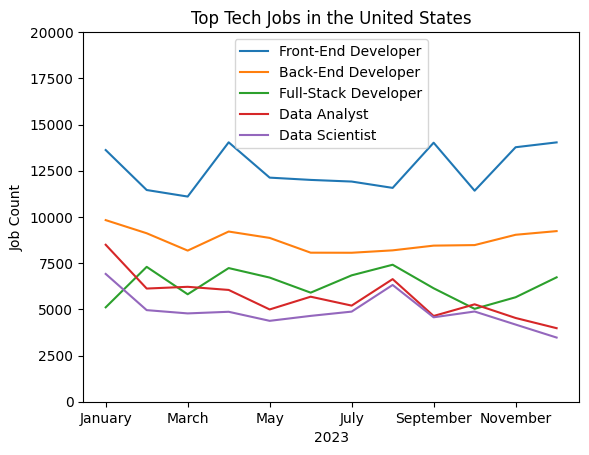

In [60]:
df_tech_jobs[top_5].plot(kind='line')
plt.title('Top Tech Jobs in the United States')
plt.xlabel('2023')
plt.ylabel('Job Count')
plt.ylim(0,20000)
plt.legend()
plt.show()